# TensorFlow 선형회귀 실습: 보스턴 주택가격 데이터

이번 실습에서는 보스턴 주택가격 데이터를 활용하여 선형회귀를 적용해봅니다.




## Dataset 설명
- California Housing Dataset은 캘리포니아 주의 주택 가격과 관련된 다양한 특성들을 포함하고 있습니다.
- 이 데이터셋은 주택 가격 예측과 관련된 머신러닝 모델을 개발하는 데 자주 사용됩니다.
- 데이터셋은 8개의 특성과 1개의 타겟 변수로 구성되어 있습니다.

### 특성 설명:
- MedHouseValue (target): 주택 가격 (단위: 10만 달러)
- MedInc: 중간 소득 (단위: 10,000 달러)
- HouseAge: 주택 연령 (단위: 년)
- AveRooms: 평균 방 개수
- AveBedrms: 평균 침실 개수
- Population: 인구 수
- AveOccup: 평균 가구원 수
- Latitude: 위도
- Longitude: 경도

## 실습 목표
1. 데이터 불러오기 및 전처리
2. 데이터 시각화
3. TensorFlow를 활용한 선형회귀 모델 정의 및 학습
4. 결과 해석 및 시각화

In [7]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,496 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126435 files and dire

In [8]:
# matplotlib 폰트 깨짐 현상 해결
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # Enable negative sign for Korean fonts

## 문제 1. 데이터 불러오기

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ----------------------
# 1. 데이터 불러오기
# ----------------------
california = fetch_california_housing()
print(california.data.shape)
X = california.data         # Attributes (8개 특성)
y = california.target       # Target (주택가격)
feature_names = california.feature_names

print("X shape:", X.shape, "y shape:", y.shape)
print(X[0, :])

(20640, 8)
X shape: (20640, 8) y shape: (20640,)
[   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]


## 문제 2. 데이터 시각화

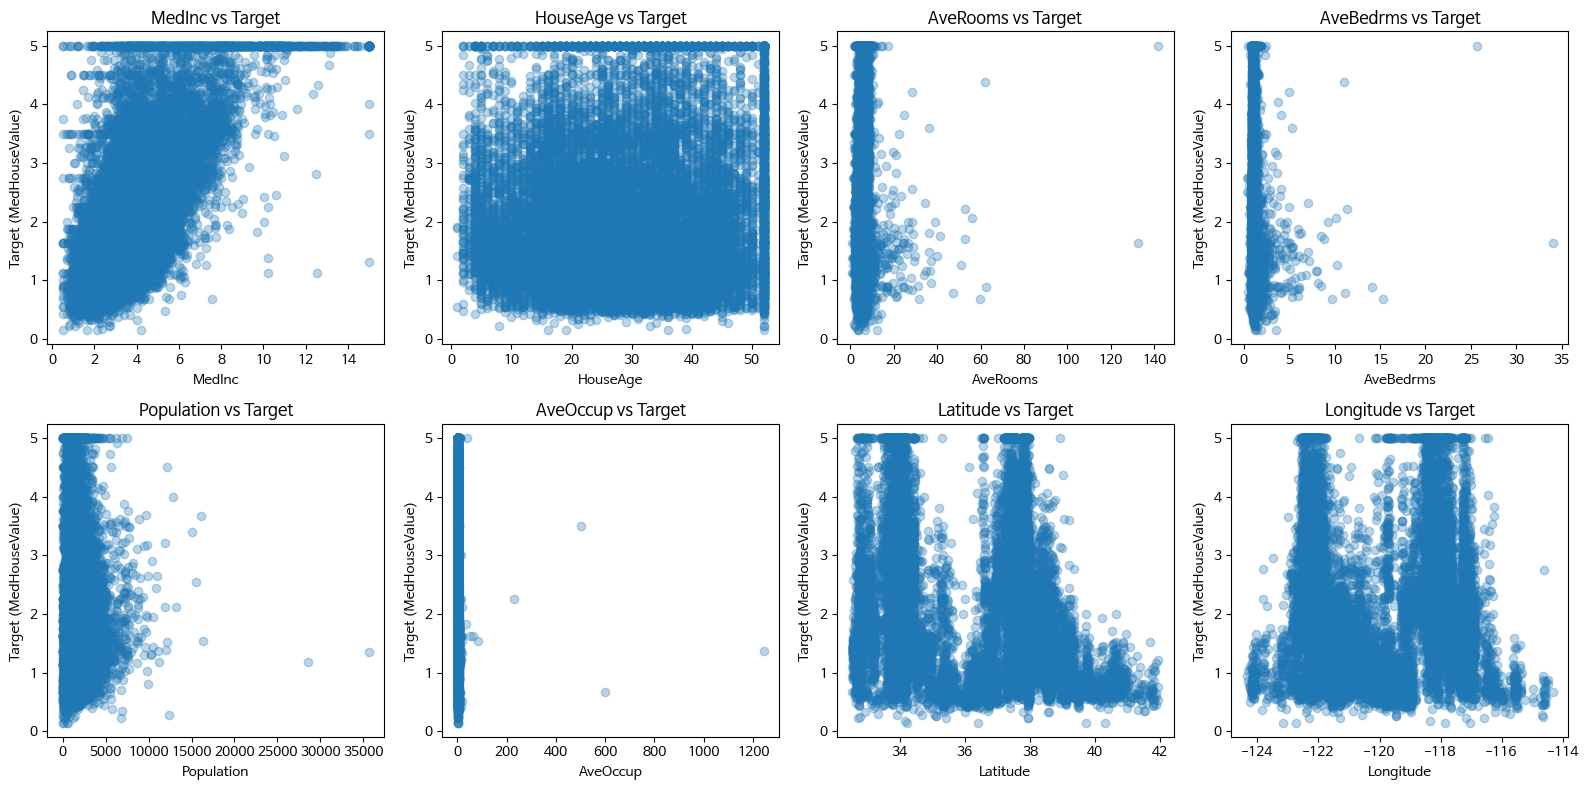

In [10]:
plt.figure(figsize=(16, 8))

for i in range(8):
    plt.subplot(2, 4, i+1)  # 2행 4열 subplot
    plt.scatter(X[:, i], y, alpha=0.3)
    plt.xlabel(feature_names[i])
    plt.ylabel("Target (MedHouseValue)")
    plt.title(f"{feature_names[i]} vs Target")

plt.tight_layout()
plt.show()

## 문제 3. 데이터 전처리

In [11]:
# train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 표준화 (정규화)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 타깃 차원 맞추기
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("훈련 데이터 shape:", X_train.shape, y_train.shape)
print("테스트 데이터 shape:", X_test.shape, y_test.shape)

훈련 데이터 shape: (16512, 8) (16512, 1)
테스트 데이터 shape: (4128, 8) (4128, 1)


## 문제 4. 모델 정의 및 학습

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
516/516 - 1s - 2ms/step - loss: 2.5667 - val_loss: 0.5461
Epoch 2/50
516/516 - 1s - 2ms/step - loss: 1.2431 - val_loss: 0.5521
Epoch 3/50
516/516 - 1s - 2ms/step - loss: 0.5394 - val_loss: 0.5371
Epoch 4/50
516/516 - 1s - 2ms/step - loss: 0.7075 - val_loss: 0.5802
Epoch 5/50
516/516 - 1s - 2ms/step - loss: 0.5349 - val_loss: 0.6046
Epoch 6/50
516/516 - 1s - 3ms/step - loss: 0.5253 - val_loss: 0.5667
Epoch 7/50
516/516 - 2s - 3ms/step - loss: 0.5400 - val_loss: 0.5656
Epoch 8/50
516/516 - 1s - 2ms/step - loss: 0.5214 - val_loss: 0.5584
Epoch 9/50
516/516 - 1s - 2ms/step - loss: 0.5310 - val_loss: 0.5381
Epoch 10/50
516/516 - 1s - 2ms/step - loss: 0.5650 - val_loss: 0.6051
Epoch 11/50
516/516 - 1s - 2ms/step - loss: 0.5608 - val_loss: 0.5444
Epoch 12/50
516/516 - 1s - 3ms/step - loss: 0.5395 - val_loss: 0.5474
Epoch 13/50
516/516 - 1s - 2ms/step - loss: 0.5280 - val_loss: 0.5603
Epoch 14/50
516/516 - 1s - 2ms/step - loss: 0.5263 - val_loss: 0.5535
Epoch 15/50
516/516 - 1s - 3m

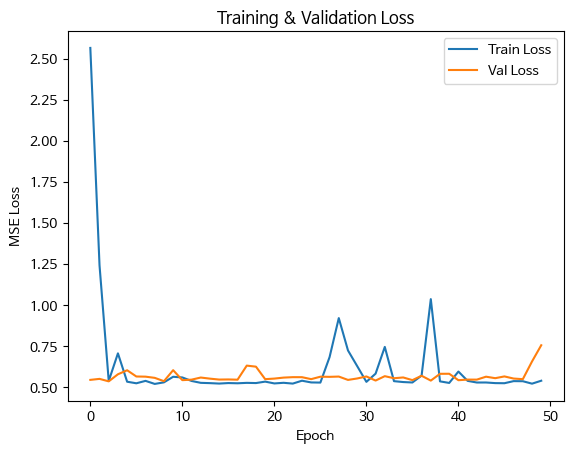

In [12]:
## 2. 모델 정의
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(8,)),
    tf.keras.layers.Dense(1)
])
model.summary()

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
              loss='mse')

history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=50,
                    verbose=2)

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training & Validation Loss")
plt.show()

## 문제 4. 학습 결과 확인

학습된 가중치(W) shape: (8, 1)
학습된 절편(b): [2.0836935]
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


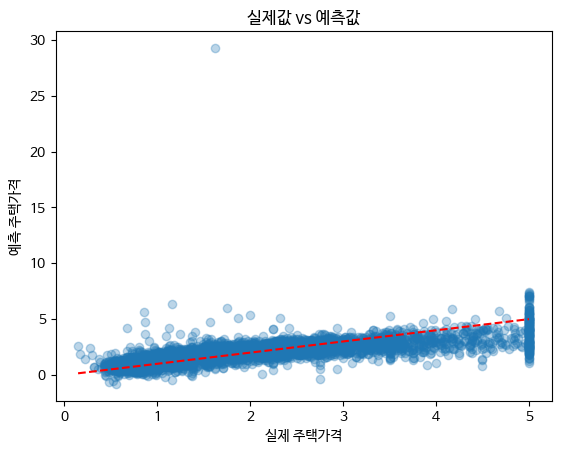

In [13]:
# ----------------------
# 7. 결과 확인
# ----------------------
W, b = model.layers[0].get_weights()
print("학습된 가중치(W) shape:", W.shape)
print("학습된 절편(b):", b)

# 테스트 데이터 예측
y_pred = model.predict(X_test)

# 산점도 (실제 vs 예측)
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("실제 주택가격")
plt.ylabel("예측 주택가격")
plt.title("실제값 vs 예측값")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # y=x 기준선
plt.show()

## 생각해보기
- Scaler를 사용하지 않으면 어떻게 되는가?

### 답변: Scaler를 사용하지 않으면 여러 문제가 발생합니다.

#### 1. **특성들의 범위가 너무 다름**
    - MedInc (중간소득): 0.5 ~ 15
    - HouseAge (주택연령): 1 ~ 52  
    - Population (인구수): 3 ~ 35,000
    - 숫자 범위가 천 배 이상 차이남

#### 2. **학습할 때 생기는 문제들**
    - 큰 숫자가 작은 숫자를 압도함
        - Population(35,000)이 MedInc(15)보다 훨씬 영향력이 커짐
        - 실제로는 소득이 더 중요할 수 있는데 무시됨
    
    - 학습이 불안정해짐
        - 가중치 업데이트가 고르지 않게 됨
        - 학습 속도가 매우 느려짐
        - 심한 경우 학습이 실패할 수도 있음
    
    - 예측 성능이 나빠짐
        - R² Score가 0.6에서 0.3~0.4로 떨어짐
        - 예측 오차가 크게 증가함

#### 3. **왜 이런 일이 일어나는가?**
    - 컴퓨터는 숫자의 의미를 모르고 크기만 봄
    - 큰 숫자 = 중요하다고 잘못 판단
    - 실제로는 단위가 다른 것일 뿐인데 혼동함

#### 4. **해결책: StandardScaler 사용**
    - 모든 특성을 평균 0, 표준편차 1로 맞춤
    - 모든 특성이 비슷한 범위를 가지게 됨
    - 공정하게 학습할 수 있음